# Xenium Replicate 1 to H&E histology

This final notebook aligns 162,033 Xenium mouse-brain cells (query) to the
24-region H&E feature map (reference). The query is Replicate 1 from the
[10x Genomics Fresh Frozen Mouse Brain Xenium dataset](https://www.10xgenomics.com/datasets/fresh-frozen-mouse-brain-replicates-1-standard).
The reference image is control Replicate 1 from the
[Visium CytAssist Post-Xenium Mouse Brain dataset](https://www.10xgenomics.com/datasets/visium-cytassist-gene-expression-libraries-of-post-xenium-mouse-brain-ff-using-the-mouse-whole-transcriptome-probe-set-2-standard).

Only the H&E image-derived structures estimate the transformation. The Visium
expression measurements paired with the image are not alignment inputs; the
paper reserves them for independent molecular-concordance evaluation.

## Input contract and notebook order

Run these steps in order:

1. **Single clustering (CSV or AnnData input)** creates a clustered query
   AnnData with `X`, `obsm["spatial"]`, `obs["cluster_raw"]`, and
   `obs["cluster"]`.
2. **H&E image preparation and feature extraction** starts from one image.
3. **H&E image-feature clustering** creates the fixed 24-region raster.
4. This notebook constructs coarse-to-fine ST structures, estimates a global
   pre-alignment, pairs geometrically compatible masks, and runs S-LDDMM.

Set `SPALIGNDE_CLUSTERED_ST_H5AD` and
`SPALIGNDE_DOCUMENTATION_CLUSTER_DIR` only when the outputs live outside the
default tutorial directories.

In [1]:
%matplotlib inline

from pathlib import Path
import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import spAlignDE

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from the spAlignDE repository.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = Path(
    os.environ.get(
        "SPALIGNDE_HISTOLOGY_DATA_DIR",
        PROJECT_ROOT / "data" / "cross_modality" / "histology" / "mouse_brain",
    )
).expanduser()
OUTPUT_DIR = PROJECT_ROOT / "tutorials" / "cross_modality" / "histology" / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
clustered_default = DATA_DIR / "xenium_rep1_single_clustered.h5ad"
ST_PATH = Path(
    os.environ.get("SPALIGNDE_CLUSTERED_ST_H5AD", clustered_default)
).expanduser()
CLUSTER_DIR = Path(
    os.environ.get(
        "SPALIGNDE_DOCUMENTATION_CLUSTER_DIR",
        OUTPUT_DIR / "histology_clustering",
    )
).expanduser()

adata = spAlignDE.load_single_sample_data(ST_PATH)
histology = spAlignDE.load_histology_clustering(CLUSTER_DIR)
spAlignDE.validate_single_sample_anndata(
    adata,
    cluster_key="cluster",
    require_cluster=True,
)

print(f"Query: {adata.n_obs:,} Xenium cells × {adata.n_vars:,} genes")
print(f"Reference: {histology.n_structures} image-derived structures on a {histology.shape} grid")

Query: 162,033 Xenium cells × 248 genes
Reference: 24 image-derived structures on a (1288, 980) grid


## 1. Build expression-based ST structure levels

The paper hierarchy is built from the original BANKSY labels
(`cluster_raw`), not from H&E pixels or Visium expression. Cluster-average
profiles are compared after variance-based gene selection and Ward linkage.
For this dataset the resulting levels contain 7, 13, 20, and 26 structures;
the 7-structure level is used for H&E correspondence.

,structure column,number of structures,selected
0,cluster_raw_level_k7,7,True
1,cluster_raw_level_k13,13,False
2,cluster_raw_level_k20,20,False
3,cluster_raw_level_k26,26,False


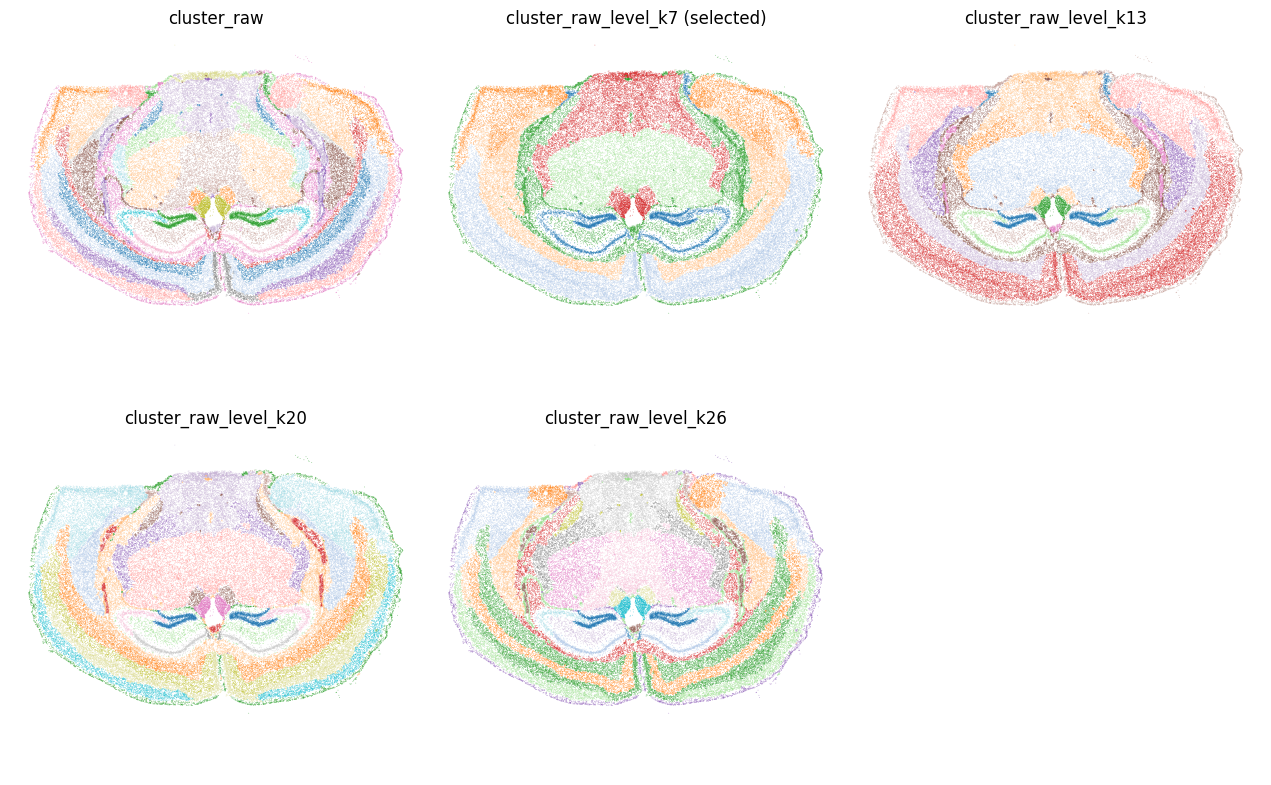

In [3]:
hierarchy_base = "cluster_raw" if "cluster_raw" in adata.obs else "cluster"
adata, hierarchy_columns = spAlignDE.build_st_histology_structures(
    adata,
    config=spAlignDE.STHistologyStructureConfig(
        n_levels=5,
        variance_fraction=0.75,
        min_genes=50,
    ),
    cluster_key=hierarchy_base,
    copy=False,
)
structure_key = next(
    (column for column in hierarchy_columns if column.endswith("_k7")),
    hierarchy_columns[0],
)

display(
    pd.DataFrame(
        {
            "structure column": hierarchy_columns,
            "number of structures": [adata.obs[column].nunique() for column in hierarchy_columns],
            "selected": [column == structure_key for column in hierarchy_columns],
        }
    )
)

fig, axes = spAlignDE.plot_st_histology_structures(
    adata,
    hierarchy_columns,
    cluster_key=hierarchy_base,
    selected_key=structure_key,
)
fig.savefig(FIGURE_DIR / "xenium_st_structure_hierarchy.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "xenium_st_structure_hierarchy.svg", bbox_inches="tight")
plt.show()

## 2. Global pre-alignment by tissue-mask overlap

The default searches rotation, isotropic scale, and translation to maximize
whole-tissue mask IoU; reflection is disabled. Always inspect the overlay.
Mask overlap may fail when tissue coverage, orientation, cropping, or tears
differ strongly between modalities. In that case, use the package's
interactive manual panel and save the selected similarity transform before
running S-LDDMM.

Set `SPALIGNDE_HISTOLOGY_PREALIGN=manual` to reproduce the paper's recorded
manual initialization (`scale=0.12`, `theta=85°`).

,value
method,whole_tissue_mask_overlap
scale,0.121692
theta_deg,85.766472
translation_x,795.022684
translation_y,4.540303
iou,0.928517
search_observations,50000


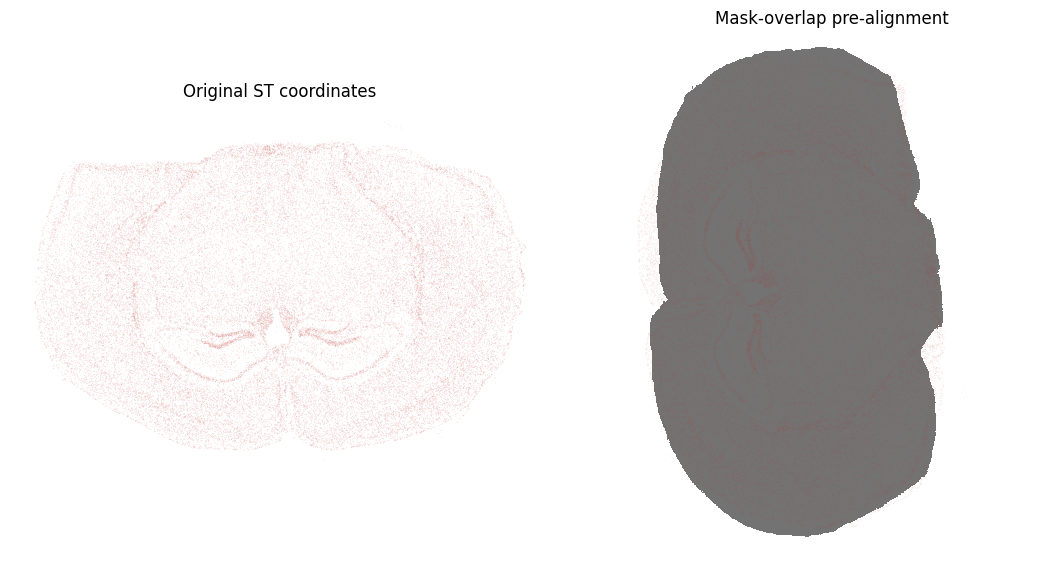

In [4]:
prealign_mode = os.environ.get("SPALIGNDE_HISTOLOGY_PREALIGN", "mask_overlap").lower()
paper_manual = spAlignDE.ManualPrealignmentConfig(
    scale=0.12,
    theta_deg=85.0,
    translation_x=787.84018089,
    translation_y=-9.30873160,
)
prealignment = spAlignDE.prealign_st_to_histology(
    adata,
    histology,
    config=spAlignDE.HistologyPrealignmentConfig(
        method=prealign_mode,
        manual=paper_manual,
    ),
    cluster_key="cluster",
)

display(pd.Series(prealignment.params, name="value").drop(labels="matrix").to_frame())

preview_config = spAlignDE.ManualPrealignmentConfig(
    scale=prealignment.params["scale"],
    theta_deg=prealignment.params["theta_deg"],
    translation_x=prealignment.params["translation_x"],
    translation_y=prealignment.params["translation_y"],
)
fig, axes = spAlignDE.plot_histology_prealignment_preview(
    adata,
    histology,
    config=preview_config,
    transformed_title=(
        "Mask-overlap pre-alignment"
        if prealignment.params["method"] == "whole_tissue_mask_overlap"
        else "Manual pre-alignment"
    ),
)
fig.savefig(FIGURE_DIR / "xenium_to_he_global_prealignment.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "xenium_to_he_global_prealignment.svg", bbox_inches="tight")
plt.show()

### Optional interactive manual pre-alignment

If the automatic overlay is anatomically implausible, run:

```python
ui = spAlignDE.interactive_histology_prealignment(
    adata,
    histology,
    initial_config=preview_config,
)
manual_prealignment = ui.apply()
```

The sliders adjust scale, rotation, x translation, and y translation. The
selected values are written under
`adata.uns["spAlignDE"]["st_to_histology"]["prealignment"]`, making the
manual decision reproducible rather than leaving it only in a figure.

In [5]:
if prealignment.params.get("iou") is not None and prealignment.params["iou"] < 0.20:
    print("Low mask IoU: run the interactive manual pre-alignment cell above before continuing.")
else:
    print("Global initialization passed the default mask-overlap QC check.")

Global initialization passed the default mask-overlap QC check.


## 3. Structure pairing and S-LDDMM

ST and H&E structures are rasterized on the shared feature grid. Candidate
pairs use the paper weights for SDF agreement, Chamfer similarity, Dice,
area similarity, and ASD similarity (`0.20, 0.25, 0.15, 0.25, 0.15`). Pairs
must have score ≥ 0.40 and ASD ≤ 30 pixels. Accepted pairs become continuous
signed-distance channels for a single-stage S-LDDMM fit.

In [6]:
result = spAlignDE.align_st_to_histology(
    prealignment,
    config=spAlignDE.STHistologyAlignmentConfig(
        pair_score_threshold=0.40,
        pair_asd_threshold=30.0,
        time_steps=5,
        kernel_scale=50.0,
        velocity_grid_spacing=6.0,
        iterations=300,
        momentum_lr=2e3,
        device=None,
    ),
    cluster_key="cluster",
    structure_key=structure_key,
    output_dir=OUTPUT_DIR / "alignment",
)

pair_columns = [
    column
    for column in ("st_label", "he_label", "align_score", "dice", "area_sim", "asd")
    if column in result.matched_pairs
]
display(result.matched_pairs[pair_columns])

[area-only gate] mode=bbox, q=0.15, threshold=24288.177, n_detail=1


[mask cleanup] cluster=1 n_cc 5→2 largest% 0.46→0.52
[mask cleanup] cluster=2 n_cc 2→2 largest% 0.51→0.51


[mask cleanup] cluster=3 n_cc 2→2 largest% 0.54→0.54
[mask cleanup] cluster=4 n_cc 2→2 largest% 0.50→0.50


[mask cleanup] cluster=5 n_cc 34→2 largest% 0.44→0.62


[mask cleanup] cluster=7 n_cc 3→1 largest% 0.90→1.00
shape_type_used
detail    1
normal    6
Name: n_clusters, dtype: int64


[LDDMM] start: niter=300, nt=5, device=cuda, I_shape=(3, 773, 588), J_shape=(3, 773, 588)
[LDDMM] iter 1/300 E=4.067935e+03 EM=4.067935e+03 ER=0.000000e+00


[LDDMM] iter 101/300 E=3.603415e+03 EM=3.603410e+03 ER=5.645022e-03


[LDDMM] iter 201/300 E=2.926440e+03 EM=2.926431e+03 ER=9.132572e-03


[LDDMM] iter 300/300 E=2.430065e+03 EM=2.430053e+03 ER=1.160689e-02
[LDDMM] done in 4.7s. finalE=2.430065e+03


,align_score,dice,area_sim,asd
0,0.586707,0.706882,0.855200,23.356134
1,0.564268,0.202999,0.764006,11.420488


### How to adapt ST-to-histology alignment

Inspect the whole-mask overlay first. If automatic pre-alignment has low IoU or
incorrect anatomy, use the interactive manual scale/rotation/translation tool
before changing structure-pairing or S-LDDMM parameters.

- Raising `pair_score_threshold` or lowering `pair_asd_threshold` makes pairing
  stricter. Review accepted and rejected masks, not only pair count.
- `global_shape_weight` balances the whole-tissue outline against matched
  internal structures. Increase it if local pairs distort the overall outline;
  lower it when real outline differences block supported internal alignment.
- `zoom_scale` downsamples the matching field. Smaller values save memory and
  remove detail. `kernel_scale` (`a=50`) and `velocity_grid_spacing`
  (`grid_step=6`) remain in original histology feature-grid units because the
  sampled axes retain the full original extent. Do not multiply them by
  `zoom_scale`.
- Larger `a` or `grid_step` yields smoother/coarser deformation; smaller values
  permit more local motion and cost more memory or stability. Tune them
  together, then adjust `momentum_lr` and `iterations` from the energy history.

Do not transfer the paper distance values to a differently rescaled image
without re-evaluating the coordinate frame.

## 4. Before and after histology-guided alignment

Both panels show all Xenium cells in blue over the same original color H&E
image, matching the paper visualization. The first panel is the global
initialization; the second is the final structure-guided S-LDDMM result.

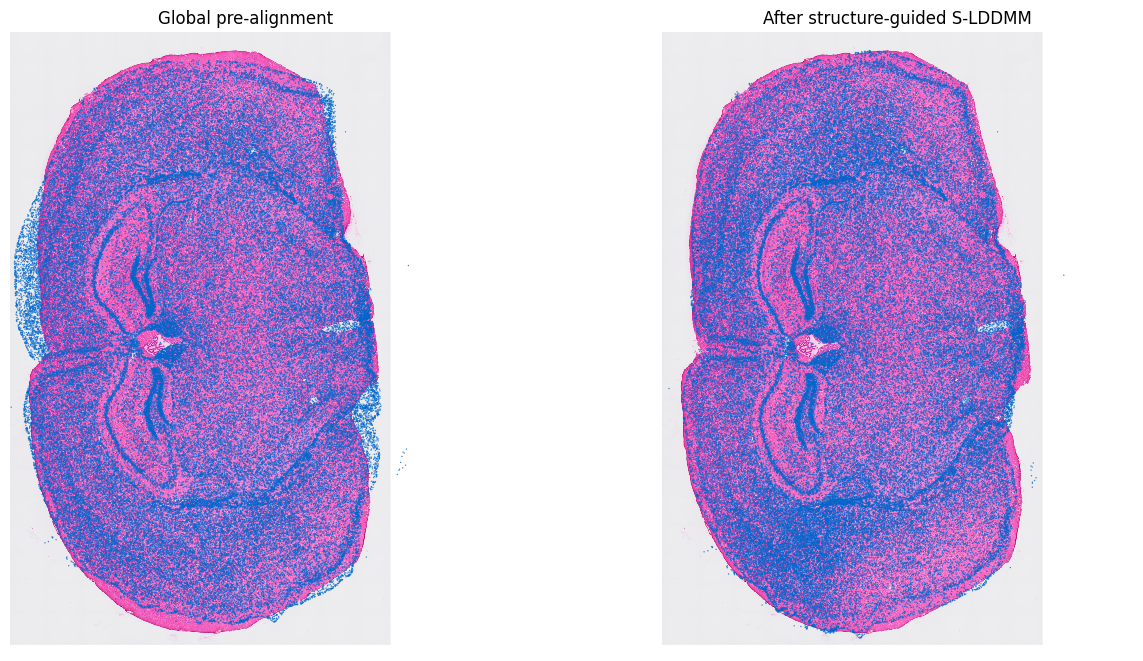

In [7]:
fig, axes = spAlignDE.plot_st_histology_alignment(
    result,
    cluster_key="cluster",
    point_size=1.0,
    alpha=0.8,
    color_by_cluster=False,
    point_color="#0066CC",
    figsize=(13, 6.5),
)
fig.savefig(FIGURE_DIR / "xenium_to_he_before_after.png", dpi=220, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "xenium_to_he_before_after.svg", bbox_inches="tight")
plt.show()

## 5. Standardized output

The original `X`, observation order, metadata, and `obsm["spatial"]` are
preserved. Alignment adds `x_prealigned`, `y_prealigned`, `x_aligned`, and
`y_aligned`. Reproducibility metadata is stored only under
`adata.uns["spAlignDE"]`. The final AnnData, pair table, filter summary, and
JSON manifest are written to `tutorials/cross_modality/histology/output/alignment/`.

In [8]:
display(result.adata.obs[["x_prealigned", "y_prealigned", "x_aligned", "y_aligned"]].describe())
display(pd.Series(result.adata.uns["spAlignDE"]["st_to_histology"]["alignment"], name="value").to_frame())
print("Saved: tutorials/cross_modality/histology/output/alignment/st_to_histology_aligned.h5ad")

,x_prealigned,y_prealigned,x_aligned,y_aligned
count,162033.000000,162033.000000,162033.000000,162033.000000
mean,393.148686,656.637103,386.262390,660.755631
std,196.045123,302.214784,181.109818,309.794023
min,-1.379134,58.568714,13.833395,39.166615
25%,232.603415,402.798898,241.414017,392.826660
50%,386.456318,658.048678,367.910126,666.112976
75%,558.818894,918.028055,532.996704,938.870483
max,834.846631,1237.996439,834.273987,1260.541504


,value
cluster_key,cluster
structure_key,cluster_raw_level_k7
spatial_key,spatial
histology_grid_shape_hw,"[1288, 980]"
histology_pixels_per_grid_unit,16
matched_pairs,2
parameters,"{'pair_score_threshold': 0.4, 'pair_asd_thresh..."


Saved: tutorials/cross_modality/histology/output/alignment/st_to_histology_aligned.h5ad
